In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
sf = pd.read_csv(r"C:\Users\bhaan\Documents\#Master Degree\Thesis\Thesis_project\X-ray spectrum calculations\225kVp 30deg 525Air 2Be 2Al 0Cu 0Sn 0W 0Ta 0Ti 0C 0Wa.spec")
print(sf)

    Energy[keV]  N[keV cm^2 mAs]^-1 @ 1 meter
0                           22.5  4.693140e+6
1                           23.5  5.595555e+6
2                           24.5  6.449672e+6
3                           25.5  7.257782e+6
4                           26.5  8.022512e+6
..                                        ...
198                           220.5  152294.6
199                           221.5  117591.3
200                           222.5  83284.31
201                            223.5  49537.1
202                            224.5  16370.3

[203 rows x 1 columns]


    Energy   Mass Att  Mass En Abs     Ratio
0      1.0  4078.0000   4065.00000  0.996812
1      2.0   617.3000    615.20000  0.996598
2      3.0   192.9000    191.70000  0.993779
3      4.0    82.7800     81.91000  0.989490
4      5.0    42.5800     41.88000  0.983560
5      6.0    24.6400     24.05000  0.976055
6      8.0    10.3700      9.91500  0.956123
7     10.0     5.3290      4.94400  0.927754
8     15.0     1.6730      1.37400  0.821279
9     20.0     0.8096      0.55030  0.679718
10    30.0     0.3756      0.15570  0.414537
11    40.0     0.2683      0.06947  0.258927
12    50.0     0.2269      0.04223  0.186117
13    60.0     0.2059      0.03190  0.154930
14    80.0     0.1837      0.02597  0.141372
15   100.0     0.1707      0.02546  0.149151
16   150.0     0.1505      0.02764  0.183654
17   200.0     0.1370      0.02967  0.216569
18   300.0     0.1186      0.03192  0.269140


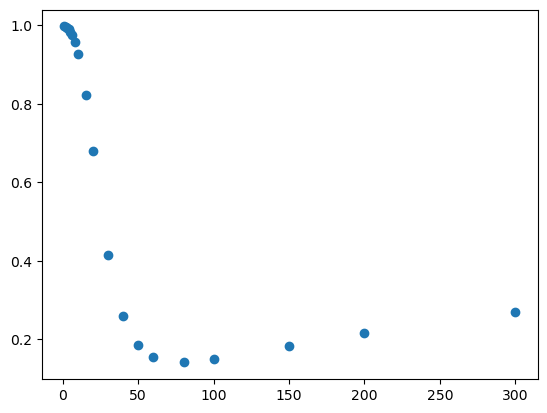

In [3]:
NIST = pd.read_excel(r"C:\Users\bhaan\Documents\#Master Degree\Thesis\Thesis_project\X-ray spectrum calculations\NIST data water.xlsx")
#convert to keV
NIST['Energy'] = 1000*NIST['Energy']
#Calculate mass energy absorption over mass attenuation ratio
NIST['Ratio'] = NIST['Mass En Abs']/NIST['Mass Att']
#Truncate after Energy that is relevant for us
NIST = NIST.iloc[0:NIST[NIST['Energy']>225].index.tolist()[0]+1]
#Remove 1.5 keV
NIST = NIST[NIST['Energy']!=1.5]
NIST = NIST.reset_index(drop=True)
print(NIST)

plt.scatter(NIST['Energy'], NIST['Ratio'])

In [22]:
#Make a copy for interpolation, take over values from original data
Expanded_data = pd.DataFrame(columns=['Energy', 'Mass Att', 'Mass En Abs'])
Expanded_data['Energy'] = np.arange(1, 301, 1)
for energy in Expanded_data['Energy']:
    matching_location = NIST[NIST['Energy']==energy].index.tolist()
    if matching_location:
        Expanded_data.loc[(Expanded_data['Energy']==energy), 'Mass Att'] = NIST.loc[matching_location[0], 'Mass Att']
        Expanded_data.loc[(Expanded_data['Energy']==energy), 'Mass En Abs'] = NIST.loc[matching_location[0], 'Mass En Abs']

     Energy  Mass Att Mass En Abs     Ratio
0         1    4078.0      4065.0  0.996812
1         2     617.3       615.2  0.996598
2         3     192.9       191.7  0.993779
3         4     82.78       81.91   0.98949
4         5     42.58       41.88   0.98356
..      ...       ...         ...       ...
295     296  0.119336     0.03183  0.266726
296     297  0.119152    0.031852  0.267327
297     298  0.118968    0.031875  0.267929
298     299  0.118784    0.031897  0.268534
299     300    0.1186     0.03192   0.26914

[300 rows x 4 columns]


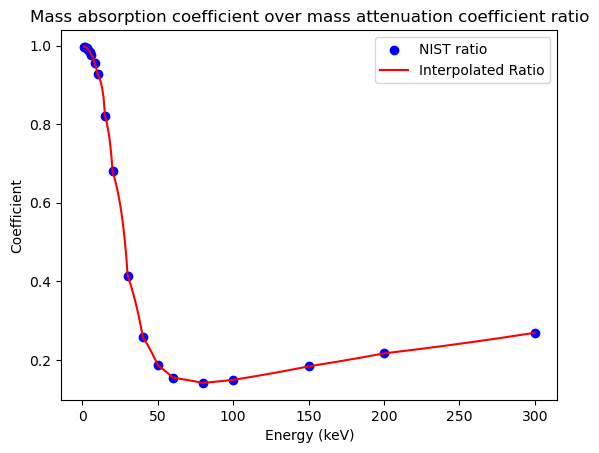

In [23]:
#Linear interpolation between existing points
for i in range(len(NIST)):
    if i!=len(NIST)-1:
        first_point = i
        second_point = i+1

        first_energy = NIST.loc[first_point, 'Energy']
        second_energy = NIST.loc[second_point, 'Energy']

        first_massatt = NIST.loc[first_point, 'Mass Att']
        second_massatt = NIST.loc[second_point, 'Mass Att']

        first_massen = NIST.loc[first_point, 'Mass En Abs']
        second_massen = NIST.loc[second_point, 'Mass En Abs']

        if (second_energy-first_energy) > 1:
            #interpolate
            interpolated_energies = np.arange(first_energy+1, second_energy, 1)
            xvals = np.array([first_energy, second_energy])

            interpolated_massatt = np.interp(interpolated_energies, xvals, np.array([first_massatt, second_massatt]))
            interpolated_massen = np.interp(interpolated_energies, xvals, np.array([first_massen, second_massen]))
            
            for en in interpolated_energies:
                Expanded_data.loc[Expanded_data['Energy']==en,'Mass Att'] = interpolated_massatt[np.where(interpolated_energies==en)]
                Expanded_data.loc[Expanded_data['Energy']==en,'Mass En Abs'] = interpolated_massen[np.where(interpolated_energies==en)]

Expanded_data['Ratio'] = Expanded_data['Mass En Abs']/Expanded_data['Mass Att']
print(Expanded_data)   

plt.scatter(NIST['Energy'],NIST['Ratio'], color='b', label='NIST ratio')
plt.plot(Expanded_data['Energy'], Expanded_data['Ratio'], color='r', label='Interpolated Ratio')
plt.title('Mass absorption coefficient over mass attenuation coefficient ratio')
plt.xlabel('Energy (keV)')
plt.ylabel('Coefficient')
plt.legend()        